In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import learning_curve

3. 資料集加載與初步可視化
使用 Iris 資料集，它包含三種鸢尾花的四個特徵。

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_name  
0       0      setosa  
1       0      setosa  
2       0      setosa  
3       0      setosa  
4       0      setosa  


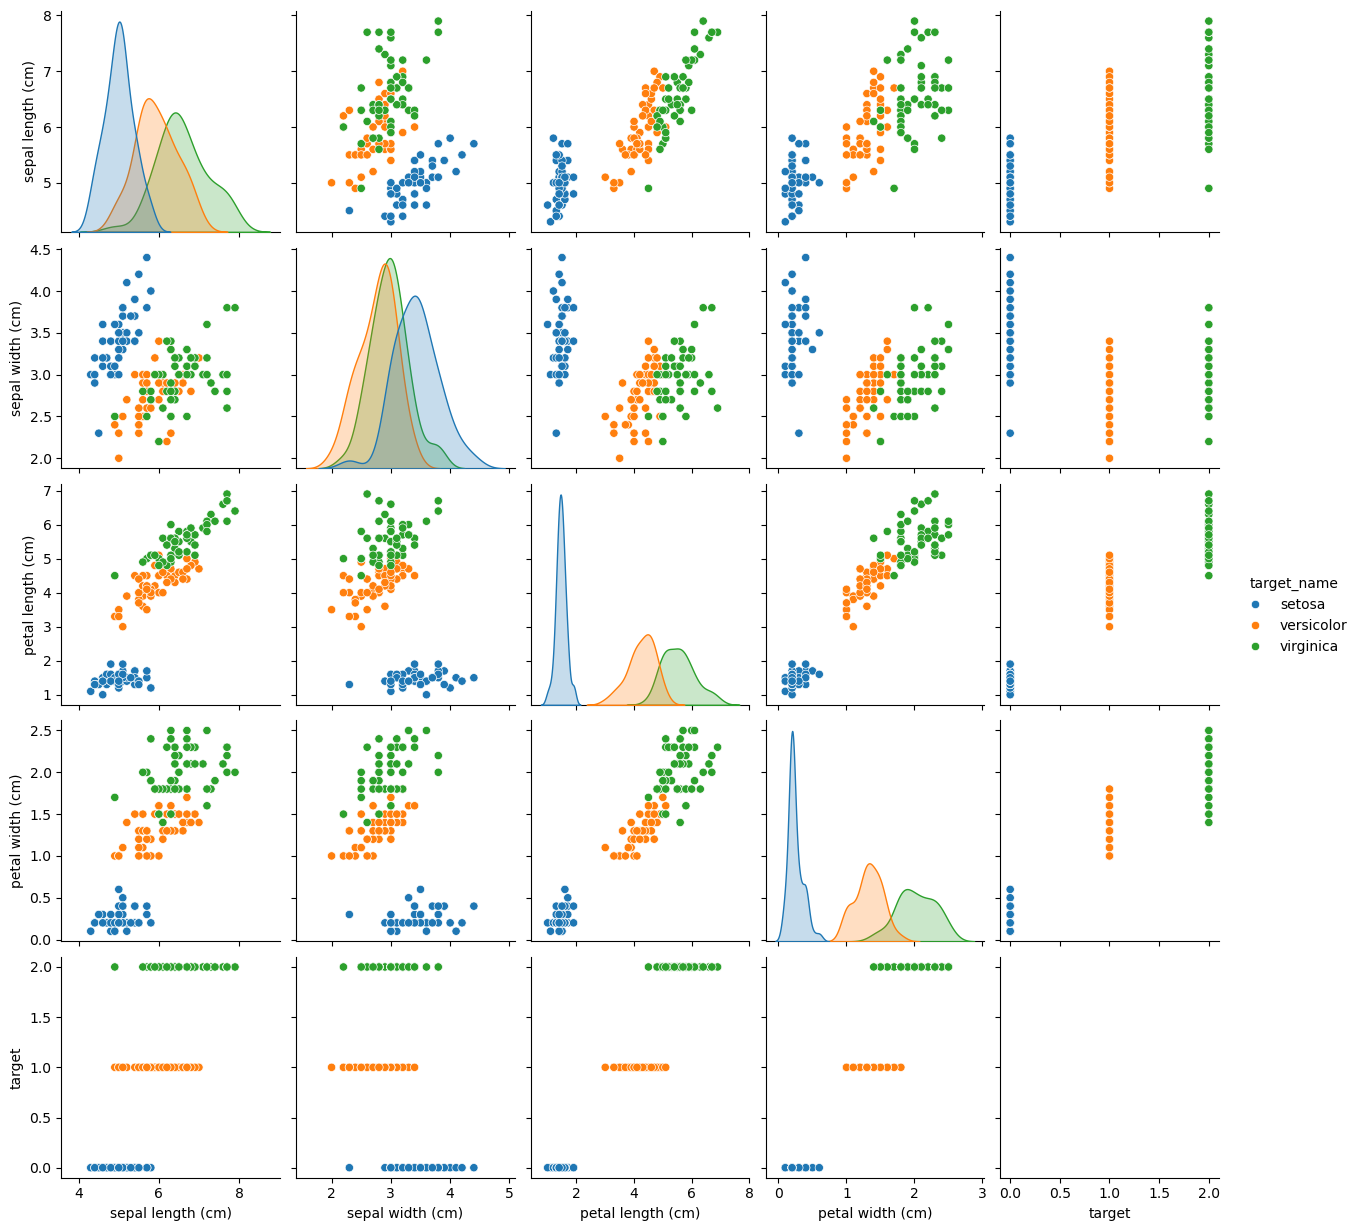

In [2]:
# 加載 Iris 資料集
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# 將數據轉換為 DataFrame，方便操作
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['target_name'] = df['target'].map(lambda x: target_names[x])

# 查看數據集的前幾行
print(df.head())

# 基本數據可視化
sns.pairplot(df, hue='target_name')
plt.show()

4. 特徵工程
在這個簡單的例子中，我們主要進行標準化處理。

In [3]:
# 標準化特徵
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

5. 訓練/測試集分割

In [4]:
# 分割數據集
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

6. 模型訓練與評估
6.1 隨機森林

In [5]:
# 建立隨機森林模型
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # 標準化
    ('classifier', RandomForestClassifier(random_state=42))
])

# 使用 GridSearchCV 調整超參數
param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20]
}
grid_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=5)
grid_rf.fit(X_train, y_train)

# 評估模型
y_pred_rf = grid_rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



6.2 貝葉斯分類

In [6]:
# 建立貝葉斯分類模型
nb_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # 標準化
    ('classifier', GaussianNB())
])
nb_pipeline.fit(X_train, y_train)

# 評估模型
y_pred_nb = nb_pipeline.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Naive Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9777777777777777
Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



6.3 支持向量機

In [7]:
# 建立 SVM 模型
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # 標準化
    ('classifier', SVC(random_state=42))
])

# 使用 GridSearchCV 調整超參數
param_grid_svm = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear', 'rbf']
}
grid_svm = GridSearchCV(svm_pipeline, param_grid_svm, cv=5)
grid_svm.fit(X_train, y_train)

# 評估模型
y_pred_svm = grid_svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9777777777777777
SVM Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



6.4 集成學習（投票分類器）

In [10]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report

# 检查每个模型是否支持 predict_proba
# 如果不支持，可以改为 voting='hard'
# 或者确保所有模型都支持 predict_proba

# 随机森林和贝叶斯分类器通常支持 predict_proba
# SVM 默认情况下不支持 predict_proba，需要设置 probability=True

# 重新定义 SVM 模型，确保支持 predict_proba
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # 标准化
    ('classifier', SVC(probability=True, random_state=42))  # 设置 probability=True
])

# 使用 GridSearchCV 调整超参数
param_grid_svm = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear', 'rbf']
}
grid_svm = GridSearchCV(svm_pipeline, param_grid_svm, cv=5)
grid_svm.fit(X_train, y_train)

# 建立集成学习模型
voting_clf = VotingClassifier(
    estimators=[
        ('rf', grid_rf.best_estimator_),  # 随机森林模型（Pipeline 对象）
        ('nb', nb_pipeline),              # 贝叶斯模型（Pipeline 对象）
        ('svm', grid_svm.best_estimator_) # SVM 模型（Pipeline 对象）
    ],
    voting='soft'  # 使用软投票（基于概率）
)

# 训练集成学习模型
voting_clf.fit(X_train, y_train)

# 评估模型
y_pred_voting = voting_clf.predict(X_test)
print("Voting Classifier Accuracy:", accuracy_score(y_test, y_pred_voting))
print("Voting Classifier Classification Report:\n", classification_report(y_test, y_pred_voting))

Voting Classifier Accuracy: 1.0
Voting Classifier Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



7. 學習曲線

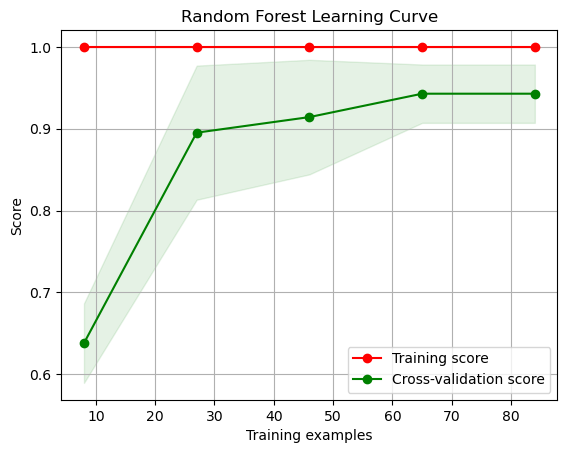

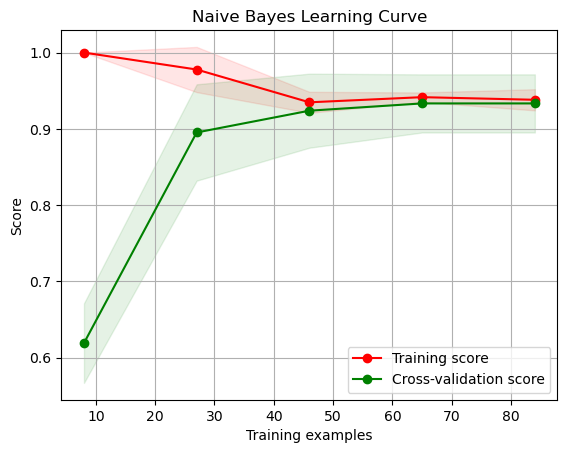

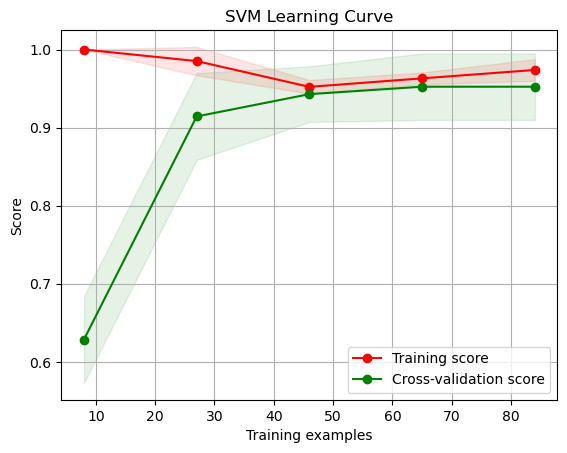

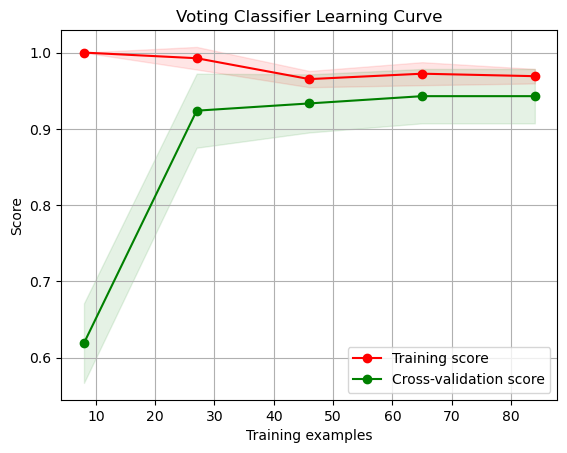

In [11]:
def plot_learning_curve(estimator, title, X, y, cv=5):
    plt.figure()
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.legend(loc="best")
    return plt

# 繪製學習曲線
plot_learning_curve(grid_rf.best_estimator_, "Random Forest Learning Curve", X_train, y_train)
plot_learning_curve(nb_pipeline, "Naive Bayes Learning Curve", X_train, y_train)
plot_learning_curve(grid_svm.best_estimator_, "SVM Learning Curve", X_train, y_train)
plot_learning_curve(voting_clf, "Voting Classifier Learning Curve", X_train, y_train)
plt.show()

8. 混淆矩陣視圖

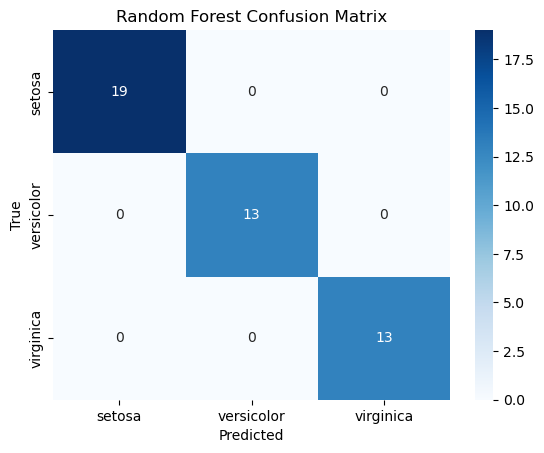

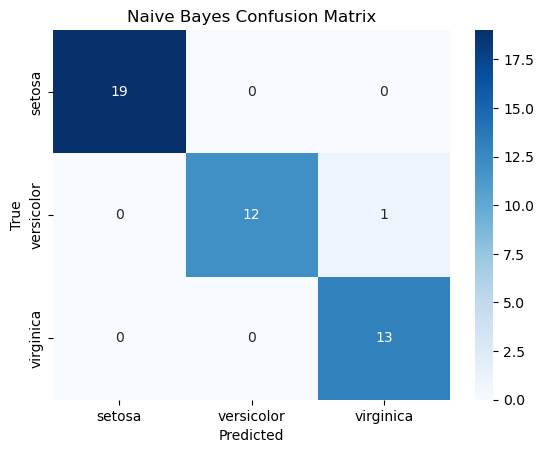

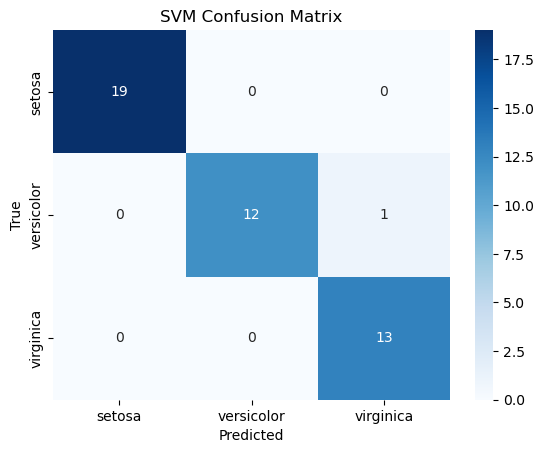

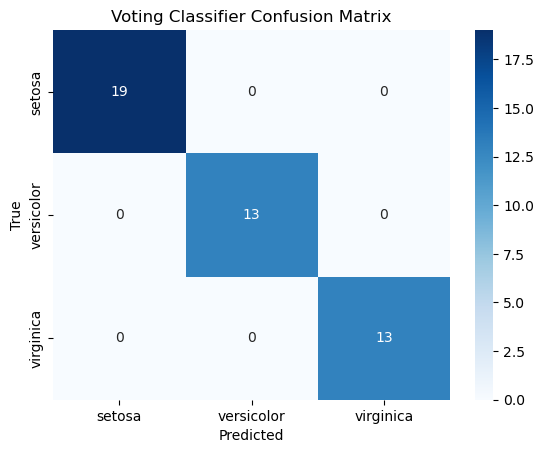

In [12]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.show()

# 繪製混淆矩陣
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_nb, "Naive Bayes Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_svm, "SVM Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_voting, "Voting Classifier Confusion Matrix")

9. 總結比較表格

In [13]:
# 比較各模型的性能
results = pd.DataFrame({
    'Model': ['Random Forest', 'Naive Bayes', 'SVM', 'Voting Classifier'],
    'Accuracy': [accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_nb),
                 accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_voting)]
})
print(results)

               Model  Accuracy
0      Random Forest  1.000000
1        Naive Bayes  0.977778
2                SVM  0.977778
3  Voting Classifier  1.000000


10. 總結
這個練習涵蓋了從數據加載、可視化、特徵工程到模型訓練、超參數調優、性能評估和學習曲線繪製的完整流程。通過比較隨機森林、貝葉斯分類、支持向量機和集成學習方法的性能，學生可以更好地理解不同算法在實際問題中的表現和適用場景。